In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
cust_acq = pd.read_csv("Customer Acqusition.csv",index_col = 'No')
spend = pd.read_csv("spend.csv", index_col = 'Sl No:')
repayment = pd.read_csv("Repayment.csv").loc[:,['Customer','Month','Amount']]

In [3]:
display(cust_acq.head())
display(spend.head())
display(repayment.head())

,Customer,Age,City,Product,Limit,Company,Segment
No,,,,,,,
1,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed
2,A2,71,CALCUTTA,Silver,100000.0,C2,Salaried_MNC
3,A3,34,COCHIN,Platimum,10000.0,C3,Salaried_Pvt
4,A4,47,BOMBAY,Platimum,10001.0,C4,Govt
5,A5,56,BANGALORE,Platimum,10002.0,C5,Normal Salary


,Customer,Month,Type,Amount
Sl No:,,,,
1,A1,12-Jan-04,JEWELLERY,485470.80
2,A1,3-Jan-04,PETRO,410556.13
3,A1,15-Jan-04,CLOTHES,23740.46
4,A1,25-Jan-04,FOOD,484342.47
5,A1,17-Jan-05,CAMERA,369694.07


,Customer,Month,Amount
0,A1,12-Jan-04,495414.75
1,A1,3-Jan-04,245899.02
2,A1,15-Jan-04,259490.06
3,A1,25-Jan-04,437555.12
4,A1,17-Jan-05,165972.88


In [4]:
cust_acq.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 1 to 100
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Customer  100 non-null    object 
 1   Age       100 non-null    int64  
 2   City      100 non-null    object 
 3   Product   100 non-null    object 
 4   Limit     100 non-null    float64
 5   Company   100 non-null    object 
 6   Segment   100 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 6.2+ KB


In [5]:
spend.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1500 entries, 1 to 1500
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Customer  1500 non-null   object 
 1   Month     1500 non-null   object 
 2   Type      1500 non-null   object 
 3   Amount    1500 non-null   float64
dtypes: float64(1), object(3)
memory usage: 58.6+ KB


In [6]:
repayment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1523 entries, 0 to 1522
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Customer  1500 non-null   object 
 1   Month     1500 non-null   object 
 2   Amount    1500 non-null   float64
dtypes: float64(1), object(2)
memory usage: 35.8+ KB


In [7]:
spend['Month']=pd.to_datetime(spend['Month'],format='mixed')
repayment['Month']=pd.to_datetime(repayment['Month'],format='mixed')

In [8]:
cust_acq.isna().sum()

Customer    0
Age         0
City        0
Product     0
Limit       0
Company     0
Segment     0
dtype: int64

In [9]:
cust_acq.duplicated().sum()

0

In [10]:
spend.isna().sum()

Customer    0
Month       0
Type        0
Amount      0
dtype: int64

In [11]:
spend.duplicated().sum()

0

In [12]:
repayment.isna().sum()

Customer    23
Month       23
Amount      23
dtype: int64

In [13]:
repayment.dropna(axis=0,how='all',inplace=True)

In [14]:
repayment.duplicated().sum()

0

In [15]:
cust_spend=pd.merge(left=cust_acq,right=spend,on='Customer',how='inner')
data=pd.merge(cust_spend,repayment,on='Customer',suffixes=('_spend', '_repayment'),how='inner')
data

,Customer,Age,City,Product,Limit,Company,Segment,Month_spend,Type,Amount_spend,Month_repayment,Amount_repayment
0,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-12,JEWELLERY,485470.80,2004-01-12,495414.75
1,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-12,JEWELLERY,485470.80,2004-01-03,245899.02
2,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-12,JEWELLERY,485470.80,2004-01-15,259490.06
3,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-12,JEWELLERY,485470.80,2004-01-25,437555.12
4,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-12,JEWELLERY,485470.80,2005-01-17,165972.88
...,...,...,...,...,...,...,...,...,...,...,...,...
37279,A96,54,CHENNAI,Silver,100000.0,C19,Salaried_Pvt,2004-01-25,BIKE,54729.66,2004-01-25,310992.30
37280,A97,58,TRIVANDRUM,Platimum,10000.0,C20,Govt,2004-01-12,AUTO,139018.26,2004-01-12,121874.90
37281,A98,51,CALCUTTA,Platimum,10001.0,C21,Normal Salary,2004-01-03,SHOPPING,284521.06,2004-01-03,337815.57
37282,A99,35,CALCUTTA,Platimum,10002.0,C22,Self Employed,2004-01-15,AIR TICKET,90184.22,2004-01-15,25682.73


In [16]:
import warnings
warnings.filterwarnings('ignore')

In [17]:
# a. In case age is less than 18, replace it with mean of age values
data.loc[data['Age']<18,'Age']=np.round(data['Age'].mean())

In [18]:
# b. In case spend amount is more than the limit, replace it with 50% of that customer’s limit.
data.loc[data['Amount_spend']>data['Limit'],'Amount_spend'] = data.loc[data['Amount_spend']>data['Limit'],'Limit']/2

In [19]:
# c. Incase the repayment amount is more than the limit, replace the repayment with thelimit.
data.loc[data['Amount_repayment']>data['Limit'],'Amount_repayment'] = data.loc[data['Amount_repayment']>data['Limit'],'Limit']

In [20]:
# a. How many distinct customers exist?
data.Customer.nunique()

100

In [21]:
# b. How many distinct categories exist?
data.Type.nunique()
#method 2 len(set(data.Type))

15

In [22]:
# c. What is the average monthly spend by customers?
data.pivot_table(values='Amount_spend',index=data['Month_spend'].dt.strftime('%B'),aggfunc='mean')
#data.groupby(data['Month_spend'].dt.strftime('%B')).Amount_spend.mean()


,Amount_spend
Month_spend,
April,138957.484445
August,171892.475911
December,114736.237214
February,159385.148924
January,155942.996660
July,172496.044621
June,185539.517389
March,138588.307050
May,161558.548503


In [23]:
# d. What is the average monthly repayment by customers?
data.groupby(data['Month_repayment'].dt.strftime('%B')).Amount_repayment.mean()

Month_repayment
April        171751.826384
August       167324.070032
December     200137.983477
February     166728.011417
January      168675.745954
July         184579.327064
June         117505.962450
March        160361.672881
May          194271.467485
November     158510.801691
October      182892.193858
September    138239.376516
Name: Amount_repayment, dtype: float64

In [24]:
# e. If the monthly rate of interest is 2.9%, what is the profit for the bank for each month?
data['Repayment_month_name']=data['Month_repayment'].dt.strftime('%Y-%m')
data['Profit']=data['Amount_repayment']-data['Amount_spend']
data['Bank_Profit']=data['Profit'].apply(lambda x:x * 0.029 if x>0 else 0 )
monthly_bank_profit=data.groupby('Repayment_month_name').Bank_Profit.sum().round(2)
monthly_bank_profit

Repayment_month_name
2004-01    11745010.85
2004-02      793353.24
2004-03      812852.03
2004-04     1826641.40
2004-05     1041077.28
2004-09      517593.23
2004-11      514772.05
2005-01     1470749.28
2005-02     7225199.58
2005-04     1016035.96
2005-05     9470060.91
2005-06      936506.64
2005-07      466439.17
2005-08     1588781.48
2005-09      280752.93
2005-10      509837.79
2005-11     1938850.70
2005-12      658665.92
2006-01      593926.55
2006-02     1968169.40
2006-03     7508206.02
2006-04     4442337.52
2006-05     4170504.54
2006-06      529709.31
2006-07     1735955.76
2006-08      438794.51
2006-09      642067.58
2006-10      573270.75
2006-11      960700.60
2006-12      661315.30
Name: Bank_Profit, dtype: float64

In [25]:
# f. What are the top 5 product types?
types_amount_spend = data.groupby('Type').agg({'Amount_spend': 'sum'})
top_5_types = types_amount_spend.sort_values(by='Amount_spend', ascending=False).head(5).round()
top_5_types

,Amount_spend
Type,
CAMERA,751701147.0
PETRO,707154853.0
FOOD,547883478.0
AIR TICKET,540117988.0
TRAIN TICKET,534423948.0


In [26]:
# we can also use 
list(data['Type'].value_counts().index[:5])

['PETRO', 'CAMERA', 'FOOD', 'AIR TICKET', 'TRAIN TICKET']

In [27]:
# g. Which city is having maximum spend?
city_spend=data.pivot_table(index='City',values='Amount_spend')
city_spend.sort_values(by='Amount_spend',ascending=False).reset_index().head(1)

,City,Amount_spend
0,CALCUTTA,182577.44038


In [28]:
# h. Which age group is spending more money?
data['Age_group']=pd.cut(x=data.Age,bins=[0, 18, 30, 45, 60, 80],labels=['<18', '18–30', '31–45', '46–60', '60+'])
age_spending=data.groupby('Age_group').agg({'Amount_spend':'sum'})
age_spending=age_spending.sort_values(by='Amount_spend',ascending=False).reset_index()
display(age_spending)
print('Age group that spending more money is :',age_spending.head(1))

,Age_group,Amount_spend
0,31–45,1.860457e+09
1,18–30,1.585074e+09
2,46–60,1.317046e+09
3,60+,9.854105e+08
4,<18,0.000000e+00


Age group that spending more money is :   Age_group  Amount_spend
0     31–45  1.860457e+09


In [29]:
#i. Who are the top 10 customers in terms of repayment?
top_10_cust=data.groupby('Customer').Amount_repayment.sum().round().iloc[:10]
top_10_cust = top_10_cust.sort_values(ascending=False)
top_10_cust

Customer
A13     296732020.0
A12     258377565.0
A14     246241328.0
A15     111108257.0
A17     105687500.0
A11      95596813.0
A1       85566450.0
A16      85196559.0
A10      66521655.0
A100        69551.0
Name: Amount_repayment, dtype: float64

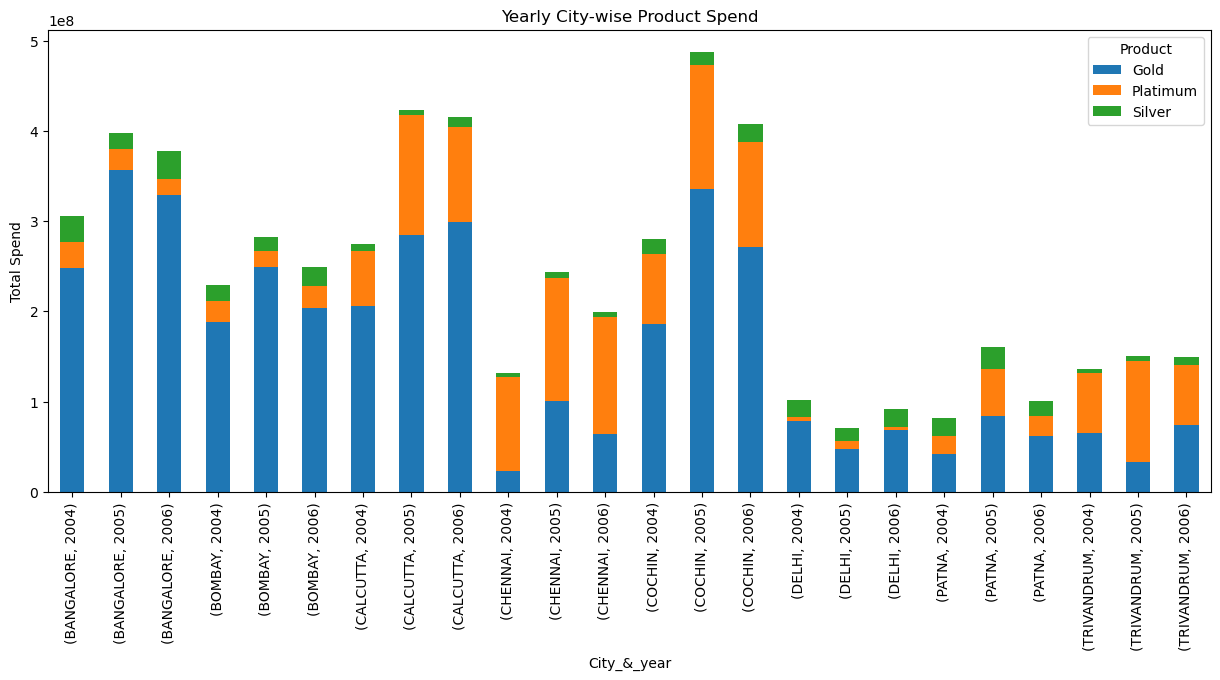

Product                        Gold     Platimum      Silver
City       Month_spend                                      
BANGALORE  2004         248006886.0   29426569.0  28450890.0
           2005         357076947.0   22425263.0  18538096.0
           2006         329375735.0   17328726.0  30685840.0
BOMBAY     2004         187728352.0   23440736.0  17558938.0
           2005         248808585.0   18337559.0  15196574.0
           2006         203544694.0   24291063.0  20870002.0
CALCUTTA   2004         206156656.0   60838321.0   7900114.0
           2005         285171826.0  132089632.0   6309944.0
           2006         299310938.0  104977287.0  11515402.0
CHENNAI    2004          23616080.0  103475013.0   4146619.0
           2005         101005531.0  136229987.0   6789321.0
           2006          64093974.0  130064754.0   5450162.0
COCHIN     2004         186219682.0   77046315.0  17184165.0
           2005         335361080.0  137271133.0  15081596.0
           2006         271183941.0  116126598.0  20428705.0
DELHI      2004          78076192.0    5103232.0  18059029.0
           2005          47318367.0    8894841.0  14137723.0
           2006          68876259.0    3182197.0  19336599.0
PATNA      2004          41661304.0   20035253.0  19749593.0
           2005          83753865.0   51898159.0  25353892.0
           2006          61456906.0   22610478.0  16950090.0
TRIVANDRUM 2004          65207777.0   66861977.0   3819369.0
           2005          33490148.0  111644742.0   5128347.0
           2006          73864193.0   66569516.0   8811362.0

In [30]:
yearly_city_product_spend=data.pivot_table(values='Amount_spend',index=['City',data.Month_spend.dt.year],columns='Product', aggfunc='sum').round()
yearly_city_product_spend.plot(kind='bar',stacked=True, figsize=(15, 6))
plt.xlabel('City_&_year')
plt.ylabel('Total Spend')
plt.title('Yearly City-wise Product Spend')
plt.show()
display(yearly_city_product_spend)

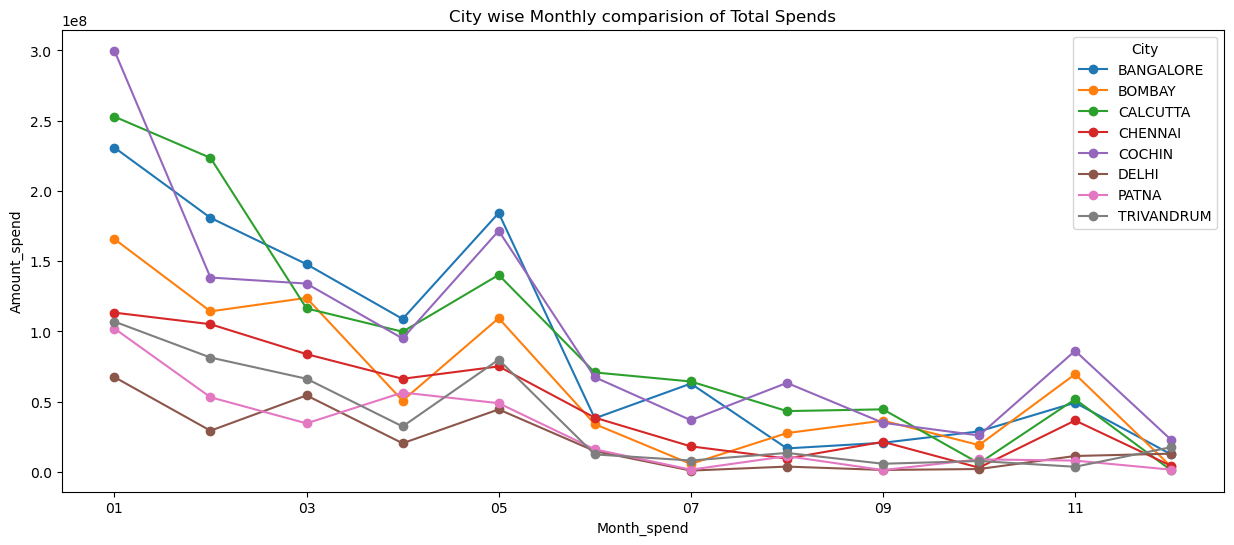

City,BANGALORE,BOMBAY,CALCUTTA,CHENNAI,COCHIN,DELHI,PATNA,TRIVANDRUM
Month_spend,,,,,,,,
01,230839628.0,165719133.0,252873939.0,113337038.0,299869625.0,67457551.0,102035738.0,106949860.0
02,180816704.0,114232208.0,223489226.0,105093547.0,138314470.0,29280123.0,53109826.0,81372841.0
03,147822553.0,123829021.0,116338019.0,83793307.0,134007251.0,54420772.0,34507875.0,66269595.0
04,108837661.0,50672026.0,99749508.0,66240612.0,94952282.0,20344424.0,56462333.0,32308128.0
05,184261031.0,109397245.0,140169027.0,75061188.0,171583556.0,44450523.0,48876602.0,79876198.0
06,38098676.0,33989962.0,70764215.0,38571507.0,67373517.0,14799531.0,16031350.0,12410442.0
07,62811919.0,5609516.0,64326095.0,18143887.0,36781493.0,900027.0,1550000.0,8075020.0
08,16695838.0,27596730.0,43250073.0,9482155.0,63316327.0,3745845.0,11183985.0,13466986.0
09,20693567.0,36466398.0,44493633.0,21374396.0,34924790.0,1350027.0,1265939.0,5767975.0


In [31]:
# a. Monthly comparison of total spends, city wise

monthly_comparision=data.pivot_table(values='Amount_spend',index=data.Month_spend.dt.strftime('%m'),columns='City',aggfunc='sum')
monthly_comparision=monthly_comparision.round()
monthly_comparision.plot(kind='line',figsize=(15, 6),marker='o')
plt.title('City wise Monthly comparision of Total Spends')
plt.ylabel('Amount_spend')
plt.show()
monthly_comparision

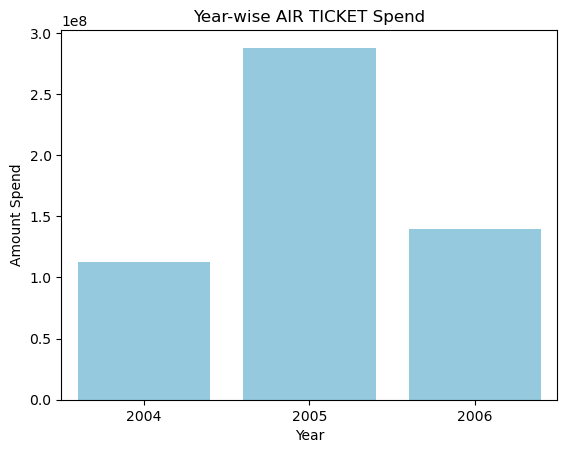

,Type,Month_spend,Amount_spend
0,AIR TICKET,2004,112682288.0
1,AIR TICKET,2005,287803079.0
2,AIR TICKET,2006,139632621.0


In [32]:
# b. Comparison of yearly spend on air tickets
filtered_data=data[data['Type']=='AIR TICKET'].loc[:,['Type','Month_spend','Amount_spend']]
atkt_spend=filtered_data.groupby(['Type',filtered_data.Month_spend.dt.year]).Amount_spend.sum()
atkt_spend=atkt_spend.reset_index().round()
sns.barplot(x='Month_spend', y='Amount_spend', data=atkt_spend, color='skyblue')
plt.title('Year-wise AIR TICKET Spend')
plt.xlabel('Year')
plt.ylabel('Amount Spend')
plt.show()
display(atkt_spend)

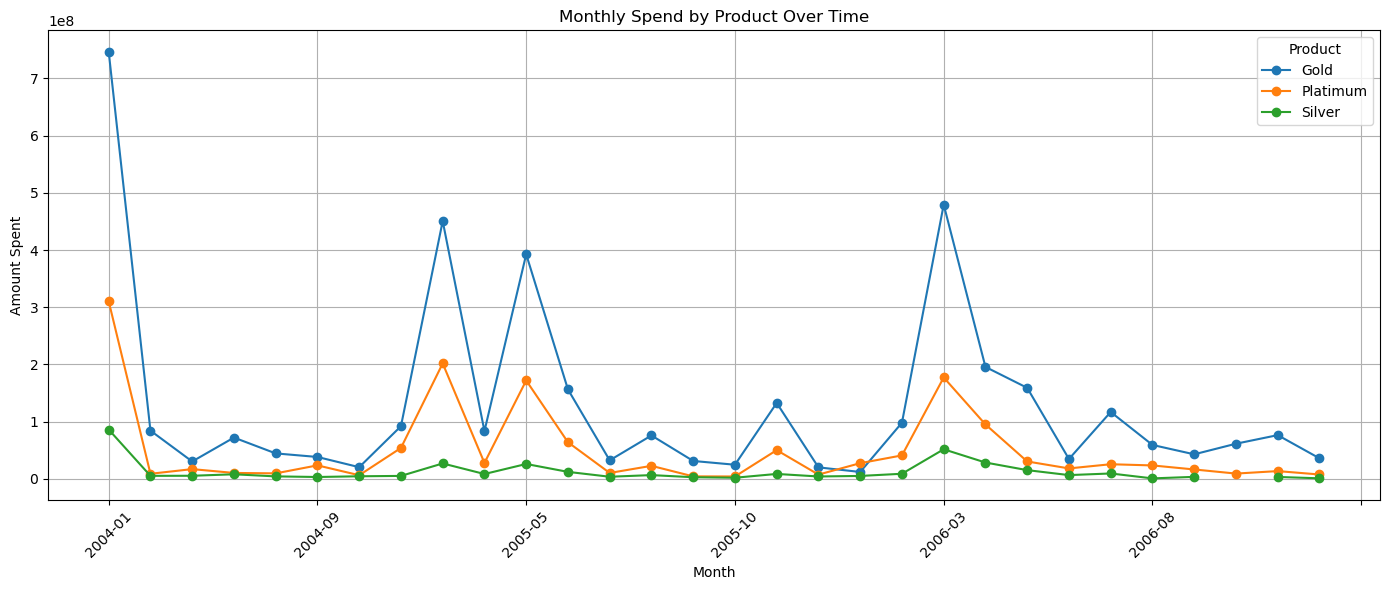

Product,Gold,Platimum,Silver
Month_spend,,,
2004-01,746710354.0,310473766.0,86159306.0
2004-02,84299429.0,8865222.0,5259030.0
2004-03,30354691.0,17016188.0,5400036.0
2004-04,72161027.0,10348746.0,7983635.0
2004-05,44493649.0,9599978.0,4316596.0
2004-09,38251815.0,23573379.0,3250054.0
2004-11,20401963.0,6350134.0,4500060.0
2005-01,92016452.0,54015230.0,5148669.0
2005-02,450587150.0,201760117.0,26922869.0


In [33]:
# c. Comparison of monthly spend for each product (look for any seasonality that exists in terms of spend)
monthly_product_comparision=data.pivot_table(values='Amount_spend',index=data.Month_spend.dt.strftime('%Y-%m'),columns='Product',aggfunc='sum')
monthly_product_comparision=monthly_product_comparision.round()
monthly_product_comparision.plot(kind='line', figsize=(14, 6), marker='o')
plt.title("Monthly Spend by Product Over Time")
plt.xlabel("Month")
plt.ylabel("Amount Spent")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
display(monthly_product_comparision)

In [71]:
def top_customers_analysis(data, product, time_period):
    import pandas as pd

    # Validate inputs
    if product not in ['Gold', 'Silver', 'Platimum']:
        raise ValueError("Product must be 'Gold', 'Silver', or 'Platimum'")
    if time_period not in ['monthly', 'yearly']:
        raise ValueError("Time period must be 'monthly' or 'yearly'")

    df = data[data['Product'] == product]

    if time_period == 'monthly':
        df['Period'] = df['Month_repayment'].dt.month
    else:
        df['Period'] = df['Month_repayment'].dt.year

    repayment_summary = df.groupby(['City', 'Customer', 'Period'])['Amount_repayment'].sum().reset_index()

    # Get top 10 customers per City and Period
    top_customers = (repayment_summary.sort_values(['City', 'Period', 'Amount_repayment'], ascending=[True, True, False]).groupby(['City', 'Period']).head(10).reset_index(drop=True))

    return top_customers


In [73]:
top_customers_analysis(data=data,product='Gold',time_period='yearly').head(50)

,City,Customer,Period,Amount_repayment
0,BANGALORE,A14,2004,8.587810e+07
1,BANGALORE,A13,2004,7.244740e+07
2,BANGALORE,A43,2004,5.910142e+07
3,BANGALORE,A1,2004,4.247636e+07
4,BANGALORE,A30,2004,2.642698e+07
5,BANGALORE,A63,2004,2.366567e+06
6,BANGALORE,A43,2005,1.242157e+08
7,BANGALORE,A13,2005,1.164879e+08
8,BANGALORE,A14,2005,7.725143e+07
9,BANGALORE,A30,2005,7.202915e+07
